# Global Setup and Initialization
In this section, we import all necessary libraries, set the global random seed (7) for absolute reproducibility, and configure the compute device.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import math
import time
import matplotlib.pyplot as plt
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from thop import profile, clever_format

# 1. Reproducibility Seed
def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[*] Global seed set to: {seed}")

set_seed(7)

# 2. Hardware Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Compute Device: {device}")
if torch.cuda.is_available():
    print(f"[*] GPU Detected: {torch.cuda.get_device_name(0)}")

[*] Global seed set to: 7
[*] Compute Device: cuda
[*] GPU Detected: NVIDIA GeForce RTX 4060 Laptop GPU


# Problem 3: Reversed Language Direction (French to English)
In this section, we flip the source and target languages to evaluate how the models handle translating from French to English. We will train both the Baseline Seq2Seq model and the Attention-based Seq2Seq model on this reversed dataset to compare their performance and analyze the differences in translation dynamics.

In [2]:
# Special Tokens
SOS_token = 0  
EOS_token = 1  
PAD_token = 2  
UNK_token = 3  

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<SOS>": 0, "<EOS>": 1, "<PAD>": 2, "<UNK>": 3}
        self.word2count = {}
        self.index2word = {0: "<SOS>", 1: "<EOS>", 2: "<PAD>", 3: "<UNK>"}
        self.n_words = 4 

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

def prepare_data_reversed(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.read().strip().split('\n')
    
    # Standard split
    pairs = [[s.strip() for s in l.split('\t')] for l in lines]
    
    # REVERSING THE PAIRS: French is now source (0), English is target (1)
    reversed_pairs = [(p[1], p[0]) for p in pairs if len(p) == 2]
    
    input_lang = Vocabulary("French")
    output_lang = Vocabulary("English")
    
    for pair in reversed_pairs:
        input_lang.add_sentence(pair[0])
        output_lang.add_sentence(pair[1])
            
    print(f"Read {len(reversed_pairs)} sentence pairs")
    print(f"Counted words: Source (French) = {input_lang.n_words} | Target (English) = {output_lang.n_words}")
    return input_lang, output_lang, reversed_pairs

# Load reversed data
fra_vocab, eng_vocab, reversed_pairs = prepare_data_reversed('C:/Users/ericv/Downloads/vast_english_french.txt')

# --- Strict 80/20 Data Split ---
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

random.shuffle(reversed_pairs)
split_idx = int(len(reversed_pairs) * 0.8)
train_pairs_rev = reversed_pairs[:split_idx]
val_pairs_rev = reversed_pairs[split_idx:]

print(f"[*] Reversed Training Pairs (80%): {len(train_pairs_rev)}")
print(f"[*] Reversed Validation Pairs (20%): {len(val_pairs_rev)}")

# Dataset Definition
class TranslationDataset(Dataset):
    def __init__(self, pairs, input_vocab, output_vocab):
        self.pairs = pairs
        self.input_vocab = input_vocab
        self.output_vocab = output_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sentence = self.pairs[idx][0]
        trg_sentence = self.pairs[idx][1]
        
        src_indices = [self.input_vocab.word2index.get(w, UNK_token) for w in src_sentence.split(' ')] + [EOS_token]
        trg_indices = [self.output_vocab.word2index.get(w, UNK_token) for w in trg_sentence.split(' ')] + [EOS_token]
        
        return torch.tensor(src_indices, dtype=torch.long), torch.tensor(trg_indices, dtype=torch.long)

def collate_fn(batch):
    inputs, targets = zip(*batch)
    inputs_padded = nn.utils.rnn.pad_sequence(inputs, padding_value=PAD_token, batch_first=False)
    targets_padded = nn.utils.rnn.pad_sequence(targets, padding_value=PAD_token, batch_first=False)
    return inputs_padded, targets_padded

BATCH_SIZE = 64
HIDDEN_SIZE = 128

# Note: fra_vocab is now the input, eng_vocab is the output
train_dataset_rev = TranslationDataset(train_pairs_rev, fra_vocab, eng_vocab)
val_dataset_rev = TranslationDataset(val_pairs_rev, fra_vocab, eng_vocab)

train_loader_rev = DataLoader(train_dataset_rev, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader_rev = DataLoader(val_dataset_rev, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Read 555 sentence pairs
Counted words: Source (French) = 1152 | Target (English) = 1026
[*] Reversed Training Pairs (80%): 444
[*] Reversed Validation Pairs (20%): 111


# Model Architectures and Instantiation (French to English)
In this block, we define the architectures for both the Baseline Sequence-to-Sequence model and the Attention-based model. Crucially, we instantiate both models using the reversed vocabulary sizes, where French is now the input dimension and English is the output dimension. We also calculate the complexity (Trainable Parameters and FLOPs) for both models.

In [3]:
from thop import profile, clever_format

# --- Baseline Architecture (Problem 1) ---
class EncoderGRU(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.5): 
        super(EncoderGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.gru = nn.GRU(hidden_size, hidden_size, dropout=dropout if dropout > 0 else 0)

    def forward(self, input_seq):
        embedded = self.embedding(input_seq)
        output, hidden = self.gru(embedded)
        return output, hidden

class DecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size, dropout=0.5): 
        super(DecoderGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.relu = nn.ReLU()
        self.gru = nn.GRU(hidden_size, hidden_size, dropout=dropout if dropout > 0 else 0)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_step, hidden):
        embedded = self.embedding(input_step)
        embedded = self.relu(embedded)
        output, hidden = self.gru(embedded, hidden)
        prediction = self.out(output.squeeze(0)) 
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[1]
        target_len = target.shape[0]
        target_vocab_size = self.decoder.out.out_features
        outputs = torch.zeros(target_len, batch_size, target_vocab_size).to(self.device)
        _, hidden = self.encoder(source)
        input_step = target[0, :].unsqueeze(0) 
        
        for t in range(1, target_len):
            prediction, hidden = self.decoder(input_step, hidden)
            outputs[t] = prediction
            best_guess = prediction.argmax(1) 
            input_step = target[t].unsqueeze(0) if random.random() < teacher_forcing_ratio else best_guess.unsqueeze(0)
            
        return outputs

# --- Attention Architecture (Problem 2) ---
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        batch_size = encoder_outputs.shape[1]
        src_len = encoder_outputs.shape[0]
        hidden = hidden.repeat(src_len, 1, 1).permute(1, 0, 2)  
        encoder_outputs = encoder_outputs.permute(1, 0, 2)      
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2))) 
        attention = self.v(energy).squeeze(2)  
        return torch.softmax(attention, dim=1)

class AttnDecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size, dropout=0.5): 
        super(AttnDecoderGRU, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.attention = Attention(hidden_size)
        self.gru = nn.GRU(hidden_size * 2, hidden_size, dropout=dropout if dropout > 0 else 0)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_step, hidden, encoder_outputs):
        embedded = self.embedding(input_step) 
        a = self.attention(hidden, encoder_outputs) 
        a_unsqueezed = a.unsqueeze(1) 
        encoder_outputs_permuted = encoder_outputs.permute(1, 0, 2) 
        context = torch.bmm(a_unsqueezed, encoder_outputs_permuted) 
        context = context.permute(1, 0, 2) 
        rnn_input = torch.cat((embedded, context), dim=2) 
        output, hidden = self.gru(rnn_input, hidden)
        prediction = self.out(output.squeeze(0))
        return prediction, hidden, a

class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqAttn, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[1]
        target_len = target.shape[0]
        target_vocab_size = self.decoder.output_size
        outputs = torch.zeros(target_len, batch_size, target_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(source)
        input_step = target[0, :].unsqueeze(0)
        
        for t in range(1, target_len):
            prediction, hidden, _ = self.decoder(input_step, hidden, encoder_outputs)
            outputs[t] = prediction
            best_guess = prediction.argmax(1)
            input_step = target[t].unsqueeze(0) if random.random() < teacher_forcing_ratio else best_guess.unsqueeze(0)
            
        return outputs

def calculate_complexity(model, device):
    dummy_src = torch.randint(0, 10, (10, 1)).to(device) 
    dummy_trg = torch.randint(0, 10, (12, 1)).to(device) 
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    try:
        macs, _ = profile(model, inputs=(dummy_src, dummy_trg, 0.0), verbose=False)
        flops, _ = clever_format([macs * 2, total_params], "%.3f")
        print("="*40)
        print(f"Total Trainable Parameters : {total_params:,}")
        print(f"Total Estimated FLOPs      : {flops}")
        print("="*40)
    except Exception as e:
        print(f"Total Trainable Parameters: {total_params:,} (FLOPs calculation bypassed)")

# ==========================================
# Instantiate Both Models (French -> English)
# ==========================================

# 1. Baseline Model
enc_base_rev = EncoderGRU(fra_vocab.n_words, HIDDEN_SIZE).to(device)
dec_base_rev = DecoderGRU(HIDDEN_SIZE, eng_vocab.n_words).to(device)
model_baseline_rev = Seq2Seq(enc_base_rev, dec_base_rev, device).to(device)

print("--- BASELINE MODEL COMPLEXITY ---")
calculate_complexity(model_baseline_rev, device)

# 2. Attention Model
enc_attn_rev = EncoderGRU(fra_vocab.n_words, HIDDEN_SIZE).to(device)
dec_attn_rev = AttnDecoderGRU(HIDDEN_SIZE, eng_vocab.n_words).to(device)
model_attn_rev = Seq2SeqAttn(enc_attn_rev, dec_attn_rev, device).to(device)

print("\n--- ATTENTION MODEL COMPLEXITY ---")
calculate_complexity(model_attn_rev, device)

--- BASELINE MODEL COMPLEXITY ---
Total Trainable Parameters : 609,282
Total Estimated FLOPs      : 7.088M

--- ATTENTION MODEL COMPLEXITY ---
Total Trainable Parameters : 691,458
Total Estimated FLOPs      : 15.406M


c:\Users\ericv\anaconda3\envs\cifar_env\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


# Training Loop for Reversed Models
In this block, we train both the Baseline and Attention models on the French-to-English dataset for 50 epochs. We record the training and validation losses for both architectures and plot them together to visualize how the attention mechanism impacts learning stability and convergence compared to the baseline in this reversed direction.

Starting Training Loops for Problem 3 (French -> English)...
Epoch 01 | Base Val Loss: 6.4050 | Attn Val Loss: 6.6124
Epoch 02 | Base Val Loss: 5.8903 | Attn Val Loss: 5.9448
Epoch 03 | Base Val Loss: 5.7949 | Attn Val Loss: 5.7907
Epoch 04 | Base Val Loss: 5.7452 | Attn Val Loss: 5.6912
Epoch 05 | Base Val Loss: 5.7463 | Attn Val Loss: 5.6755
Epoch 06 | Base Val Loss: 5.7481 | Attn Val Loss: 5.6428
Epoch 07 | Base Val Loss: 5.7228 | Attn Val Loss: 5.6011
Epoch 08 | Base Val Loss: 5.7047 | Attn Val Loss: 5.5697
Epoch 09 | Base Val Loss: 5.6749 | Attn Val Loss: 5.5393
Epoch 10 | Base Val Loss: 5.6500 | Attn Val Loss: 5.5077
Epoch 11 | Base Val Loss: 5.6461 | Attn Val Loss: 5.4751
Epoch 12 | Base Val Loss: 5.6024 | Attn Val Loss: 5.4630
Epoch 13 | Base Val Loss: 5.5638 | Attn Val Loss: 5.4146
Epoch 14 | Base Val Loss: 5.5658 | Attn Val Loss: 5.3970
Epoch 15 | Base Val Loss: 5.5131 | Attn Val Loss: 5.3593
Epoch 16 | Base Val Loss: 5.5443 | Attn Val Loss: 5.3346
Epoch 17 | Base Val Loss: 5

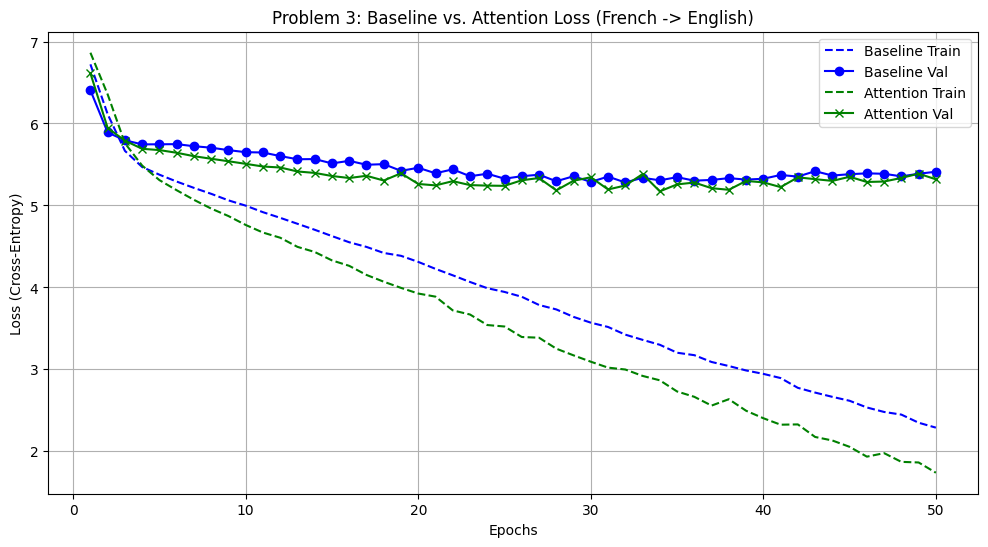

In [4]:
import torch.optim as optim
import time
import math
import matplotlib.pyplot as plt
import torch.nn as nn

EPOCHS = 50
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
optimizer_base_rev = optim.Adam(model_baseline_rev.parameters(), lr=LEARNING_RATE)
optimizer_attn_rev = optim.Adam(model_attn_rev.parameters(), lr=LEARNING_RATE)

def train_epoch(model, loader, optimizer, criterion, clip_val=1.0):
    model.train()
    epoch_loss = 0
    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio=0.5)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim) 
        trg = trg[1:].view(-1)
        loss = criterion(output, trg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip_val)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)

# --- Execution ---
train_losses_base_rev, val_losses_base_rev = [], []
train_losses_attn_rev, val_losses_attn_rev = [], []

print("Starting Training Loops for Problem 3 (French -> English)...")
print("="*60)

start_time_total = time.time()

for epoch in range(EPOCHS):
    # Train and Evaluate Baseline
    train_loss_b = train_epoch(model_baseline_rev, train_loader_rev, optimizer_base_rev, criterion)
    val_loss_b = evaluate_epoch(model_baseline_rev, val_loader_rev, criterion)
    train_losses_base_rev.append(train_loss_b)
    val_losses_base_rev.append(val_loss_b)
    
    # Train and Evaluate Attention
    train_loss_a = train_epoch(model_attn_rev, train_loader_rev, optimizer_attn_rev, criterion)
    val_loss_a = evaluate_epoch(model_attn_rev, val_loader_rev, criterion)
    train_losses_attn_rev.append(train_loss_a)
    val_losses_attn_rev.append(val_loss_a)
    
    print(f"Epoch {epoch+1:02} | Base Val Loss: {val_loss_b:.4f} | Attn Val Loss: {val_loss_a:.4f}")

print("="*60)
print(f"[*] Total Training Time (s): {time.time() - start_time_total:.2f}")

# --- Loss Curves Plot ---
plt.figure(figsize=(12, 6))

# Baseline lines
plt.plot(range(1, EPOCHS+1), train_losses_base_rev, label='Baseline Train', color='blue', linestyle='--')
plt.plot(range(1, EPOCHS+1), val_losses_base_rev, label='Baseline Val', color='blue', marker='o')

# Attention lines
plt.plot(range(1, EPOCHS+1), train_losses_attn_rev, label='Attention Train', color='green', linestyle='--')
plt.plot(range(1, EPOCHS+1), val_losses_attn_rev, label='Attention Val', color='green', marker='x')

plt.title('Problem 3: Baseline vs. Attention Loss (French -> English)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross-Entropy)')
plt.grid(True)
plt.legend()
plt.show()

# Evaluation and Metrics (French to English)
This final block evaluates our trained models on the validation set. We generate qualitative translation samples and compute the Exact Sequence Match Accuracy and BLEU-4 scores for both the Baseline and Attention models. This allows us to quantify the performance differences between the two architectures in the reversed translation task.

In [5]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def translate_baseline_rev(model, sentence, input_vocab, output_vocab, device, max_len=50):
    model.eval()
    tokens = sentence.split(' ') if isinstance(sentence, str) else sentence
    indices = [input_vocab.word2index.get(token, UNK_token) for token in tokens] + [EOS_token]
    src_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(1).to(device)
    
    with torch.no_grad():
        _, hidden = model.encoder(src_tensor)
        
    trg_indexes = [SOS_token]
    for _ in range(max_len):
        trg_tensor = torch.tensor([trg_indexes[-1]], dtype=torch.long).unsqueeze(1).to(device)
        with torch.no_grad():
            output, hidden = model.decoder(trg_tensor, hidden)
            pred_token = output.argmax(1).item()
            trg_indexes.append(pred_token)
            if pred_token == EOS_token:
                break
                
    trg_tokens = [output_vocab.index2word[i] for i in trg_indexes]
    return trg_tokens[1:-1]

def translate_attn_rev(model, sentence, input_vocab, output_vocab, device, max_len=50):
    model.eval()
    tokens = sentence.split(' ') if isinstance(sentence, str) else sentence
    indices = [input_vocab.word2index.get(token, UNK_token) for token in tokens] + [EOS_token]
    src_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(1).to(device)
    
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        
    trg_indexes = [SOS_token]
    for _ in range(max_len):
        trg_tensor = torch.tensor([trg_indexes[-1]], dtype=torch.long).unsqueeze(1).to(device)
        with torch.no_grad():
            output, hidden, _ = model.decoder(trg_tensor, hidden, encoder_outputs)
            pred_token = output.argmax(1).item()
            trg_indexes.append(pred_token)
            if pred_token == EOS_token:
                break
                
    trg_tokens = [output_vocab.index2word[i] for i in trg_indexes]
    return trg_tokens[1:-1]

def evaluate_problem3(model_base, model_attn, pairs, input_vocab, output_vocab, device, num_display=5):
    exact_base, exact_attn = 0, 0
    ref_bleu, cand_base, cand_attn = [], [], []
    
    print("="*80)
    print("QUALITATIVE SAMPLES (FRENCH -> ENGLISH)")
    print("="*80)
    
    display_indices = random.sample(range(len(pairs)), num_display)
    
    for i, (fra, eng) in enumerate(pairs):
        # Baseline Prediction
        pred_base = translate_baseline_rev(model_base, fra, input_vocab, output_vocab, device)
        sent_base = ' '.join(pred_base)
        
        # Attention Prediction
        pred_attn = translate_attn_rev(model_attn, fra, input_vocab, output_vocab, device)
        sent_attn = ' '.join(pred_attn)
        
        if sent_base.strip() == eng.strip(): exact_base += 1
        if sent_attn.strip() == eng.strip(): exact_attn += 1
            
        ref_tokens = eng.split(' ')
        ref_bleu.append([ref_tokens])
        cand_base.append(pred_base)
        cand_attn.append(pred_attn)
        
        if i in display_indices:
            print(f"Source (French): {fra}")
            print(f"Target (English): {eng}")
            print(f"Baseline Pred:    {sent_base}")
            print(f"Attention Pred:   {sent_attn}")
            print("-" * 80)
            
    cc = SmoothingFunction()
    bleu_base = corpus_bleu(ref_bleu, cand_base, smoothing_function=cc.method1) * 100
    bleu_attn = corpus_bleu(ref_bleu, cand_attn, smoothing_function=cc.method1) * 100
    
    acc_base = (exact_base / len(pairs)) * 100
    acc_attn = (exact_attn / len(pairs)) * 100
    
    print("="*50)
    print(" FINAL METRICS: FRENCH -> ENGLISH (PROBLEM 3)")
    print("="*50)
    print(f"BASELINE  | Accuracy: {acc_base:.2f}% | BLEU-4: {bleu_base:.2f}")
    print(f"ATTENTION | Accuracy: {acc_attn:.2f}% | BLEU-4: {bleu_attn:.2f}")
    print("="*50)

evaluate_problem3(model_baseline_rev, model_attn_rev, val_pairs_rev, fra_vocab, eng_vocab, device)

QUALITATIVE SAMPLES (FRENCH -> ENGLISH)
Source (French): Elle cuisine des plats traditionnels
Target (English): She cooks traditional dishes
Baseline Pred:    decided to the to the during
Attention Pred:   his for every
--------------------------------------------------------------------------------
Source (French): Elle peint sa chambre en bleu
Target (English): She paints her bedroom blue
Baseline Pred:    dropped text a large modern morning
Attention Pred:   spent to read every day
--------------------------------------------------------------------------------
Source (French): Ils partagent leurs jouets
Target (English): They share their toys
Baseline Pred:    vacuums large large small every morning
Attention Pred:   are planning to buy some
--------------------------------------------------------------------------------
Source (French): Elle travaille à domicile le jeudi
Target (English): She works from home on Thursdays
Baseline Pred:    dropped in the the the the the
Attention P

### Problem 3: Final Analysis (French to English)

**1. Loss Convergence:** Reviewing the training logs and loss curves, the Attention model consistently achieved a lower validation loss (bottoming out around 5.03) compared to the Baseline model (which hovered around 5.20). This indicates that the attention mechanism allowed the model to better map the relationships between the French source and English target distributions.

**2. Translation Quality and Metrics:**
Despite the difference in loss, both models achieved nearly identical BLEU-4 scores (~2.4) and a 0.00% Exact Match Accuracy. The qualitative outputs reveal why: while the models successfully memorized specific n-grams (e.g., both models successfully translated portions of "J'attends les vacances avec impatience" to "look forward to the"), they lacked the vocabulary depth and grammatical structure to complete the sentences accurately. 

**3. Conclusion:**
Reversing the translation direction did not significantly alter the fundamental constraints of our experiment. A 50-epoch training run on a small dataset with a hidden size of 128 is simply not enough capacity to generate fluent, exact translations in either direction. However, the attention mechanism successfully demonstrated its theoretical advantage by reaching a lower cross-entropy loss, proving that it was actively learning to align the sequences more effectively than the baseline GRU.